In [1]:
# 2026-04-16 | Goal: full 8-tilt × 3-seed EDM ablation of tilted score matching on QM9
# Runs entirely locally — no Drive, no Colab uploads.

import random, numpy as np, torch
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

In [ ]:
!git clone https://github.com/Aaryan-Patel2/TailSeeker.git /content/TailSeeker

fatal: destination path '/content/TailSeeker' already exists and is not an empty directory.


In [ ]:
# ── Cell 1: Paths ─────────────────────────────────────────────────────────
# Always run first. REPO_ROOT is validated — if detection fails, clone first:
#   !git clone https://github.com/YOUR_USER/TailSeeker.git /content/TailSeeker
# then re-run this cell.
import os, pathlib, sys

def _looks_like_repo(p):
    return pathlib.Path(p, 'src', 'losses').exists()

_nb_dir = pathlib.Path(os.path.abspath('')).resolve()
_cwd    = pathlib.Path(os.getcwd()).resolve()

_candidates = [
    _nb_dir.parent,                              # notebooks/ → repo root
    _nb_dir,
    _cwd / 'TailSeeker',                         # /content/TailSeeker (standard clone)
    pathlib.Path('/content/TailSeeker'),
    pathlib.Path('/content/drive/MyDrive/TailSeeker'),
    pathlib.Path('/content/drive/MyDrive/Projects/TailSeeker'),
]

REPO_ROOT = None
for _c in _candidates:
    if _looks_like_repo(_c):
        REPO_ROOT = str(_c)
        break

if REPO_ROOT is None:
    raise RuntimeError(
        'Cannot find TailSeeker repo. Clone it first:\n'
        '  !git clone https://github.com/YOUR_USER/TailSeeker.git /content/TailSeeker\n'
        'then re-run this cell.'
    )

# EDM and data live alongside the repo (siblings under /content or Drive)
BASE        = str(pathlib.Path(REPO_ROOT).parent)
EDM_PATH    = os.path.join(BASE, 'edm')
DATA_ROOT   = os.path.join(BASE, 'ts_data')
OUTPUT_ROOT = os.path.join(BASE, 'ts_outputs')

for d in [EDM_PATH, DATA_ROOT, OUTPUT_ROOT]:
    os.makedirs(d, exist_ok=True)

for p in [REPO_ROOT, EDM_PATH]:
    if p not in sys.path:
        sys.path.insert(0, p)

print(f'Repo:    {REPO_ROOT}')
print(f'EDM:     {EDM_PATH}')
print(f'Data:    {DATA_ROOT}')
print(f'Outputs: {OUTPUT_ROOT}')


Repo:    /content/TailSeeker
EDM:     /content/edm
Data:    /content/ts_data
Outputs: /content/ts_outputs


In [ ]:
# ── Cell 2b: Pull latest repo changes ────────────────────────────────────
# Ensures run_edm_ablation.py and all scripts are up-to-date before any
# code from the repo is executed.  Safe to re-run — git pull is idempotent.
import subprocess
r = subprocess.run(
    ['git', '-C', REPO_ROOT, 'pull', '--ff-only'],
    capture_output=True, text=True
)
print(r.stdout.strip() or '(nothing to pull)')
if r.returncode != 0:
    print('git pull failed (stderr):', r.stderr.strip())
    print('Repo may have local modifications — resolve and re-run this cell.')
else:
    print('Repo up-to-date.')


In [3]:
# ── Cell 2: Clone EDM (public GitHub, one-time) ───────────────────────────
import subprocess

EDM_REPO   = 'https://github.com/ehoogeboom/e3_diffusion_for_molecules.git'
EDM_COMMIT = ''   # pin to a SHA for reproducibility — empty = latest main

def _run(cmd):
    print(f'$ {cmd}')
    r = subprocess.run(cmd, shell=True, capture_output=True, text=True)
    if r.stdout: print(r.stdout.rstrip())
    if r.stderr: print(r.stderr.rstrip())
    r.check_returncode()

if os.path.exists(os.path.join(EDM_PATH, '.git')):
    head = subprocess.check_output(f'git -C {EDM_PATH} rev-parse HEAD', shell=True).decode().strip()
    print(f'EDM already cloned (HEAD {head[:12]})')
else:
    _run(f'git clone {EDM_REPO} {EDM_PATH}')
    if EDM_COMMIT:
        _run(f'git -C {EDM_PATH} checkout {EDM_COMMIT}')
    print(f'EDM cloned → {EDM_PATH}')

EDM already cloned (HEAD fce07d701a2d)


In [4]:
# ── Cell 3: Install dependencies (skips packages already importable) ──────
# Expected runtime: ~2-4 min on Colab (most time is torch-geometric + rdkit).
import subprocess, sys, importlib

def _pip(*args):
    r = subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', *args],
                       capture_output=True, text=True)
    if r.returncode != 0:
        print(r.stderr[-2000:])
        raise RuntimeError(f'pip install failed: {args}')

def _have(*modules):
    return all(importlib.util.find_spec(m) is not None for m in modules)

# ── PyG ────────────────────────────────────────────────────────────────────
# torch-geometric installs from PyPI directly (no wheel index needed).
# torch-scatter / torch-sparse need a versioned wheel URL — but only if
# PyG's wheel index has a build for this exact torch+CUDA combo.  If not,
# we skip them: PyG 2.x works without them for our use-case.
if not _have('torch_geometric'):
    print('Installing torch-geometric ...')
    _pip('torch-geometric')
    print('  torch-geometric installed.')
else:
    print('torch-geometric already installed — skip.')

if not _have('torch_scatter', 'torch_sparse'):
    import torch
    # torch.__version__ includes '+cuXXX' suffix in Colab — strip it.
    tv = torch.__version__.split('+')[0]   # e.g. '2.5.1'
    cv = torch.version.cuda                # e.g. '12.4' or None
    suffix = f'cu{cv.replace(".", "")}' if cv else 'cpu'
    url = f'https://data.pyg.org/whl/torch-{tv}+{suffix}.html'
    print(f'Trying scatter/sparse wheels for torch={tv} {suffix} ...')
    r = subprocess.run(
        [sys.executable, '-m', 'pip', 'install', '-q',
         'torch-scatter', 'torch-sparse', '-f', url],
        capture_output=True, text=True, timeout=120,
    )
    if r.returncode == 0:
        print('  torch-scatter / torch-sparse installed.')
    else:
        print(f'  No wheels for {tv}+{suffix} — continuing without scatter/sparse.')
        print('  (PyG 2.x works without them for EDM dataloading.)')
else:
    print('torch-scatter / torch-sparse already installed — skip.')

# ── requirements-colab.txt (rdkit, hydra, wandb, etc.) ────────────────────
if not _have('rdkit', 'hydra', 'wandb'):
    print('Installing requirements-colab.txt ...')
    _pip('-r', f'{REPO_ROOT}/requirements-colab.txt')
    print('  Done.')
else:
    print('rdkit / hydra / wandb already installed — skip.')

# ── EDM requirements ───────────────────────────────────────────────────────
if not _have('torch_ema'):
    print('Installing EDM requirements ...')
    _pip('-r', f'{EDM_PATH}/requirements.txt')
    print('  Done.')
else:
    print('EDM requirements already installed — skip.')

# ── TailSeeker editable install ────────────────────────────────────────────
# Always re-run: editable install is idempotent and _have('src') is unreliable
# (src is not a top-level package name that find_spec can resolve cleanly).
print('Installing TailSeeker in editable mode ...')
_pip('-e', REPO_ROOT)
print('  Done.')

print('\nAll deps ready.')


torch-geometric already installed — skip.
torch-scatter / torch-sparse already installed — skip.
rdkit / hydra / wandb already installed — skip.
Installing EDM requirements ...
  Done.
Installing TailSeeker in editable mode ...
  Done.

All deps ready.


In [ ]:
# ── Cell 4: Verify imports + device ──────────────────────────────────────
import torch

device = 'cuda' if torch.cuda.is_available() else 'cpu'
if device == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name(0)}')
    print(f'VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')
else:
    print('CPU only — runs will be slow (expected on WSL2 dev box)')

from src.losses import term_aggregate, TiltedScoreMatchingLoss, MultiObjectiveTiltedLoss
from src.models.edm_adapter import EDMAdapter
from src.utils import set_seed
print('TailSeeker imports: OK')

import qm9.utils as qm9_utils
print('EDM imports: OK')

from rdkit import Chem
from rdkit.Chem import QED
print('RDKit: OK')

x = torch.tensor([1.0, 2.0, 3.0])
assert torch.allclose(term_aggregate(x, tilt=0.0), x.mean(), atol=1e-7)
print('term_aggregate sanity: OK')

GPU: NVIDIA A100-SXM4-40GB
VRAM: 42.4 GB
TailSeeker imports: OK
EDM imports: OK
RDKit: OK
term_aggregate sanity: OK


In [ ]:
# ── Cell 5: Download QM9 (~100 MB, cached after first run) ────────────────
# QM9Dataset auto-downloads via PyG on first instantiation; no download= kwarg.
from src.data.qm9 import QM9Dataset

print(f'Downloading / verifying QM9 at {DATA_ROOT} ...')
for split in ('train', 'val', 'test'):
    ds = QM9Dataset(root=DATA_ROOT, split=split, max_atoms=29)
    print(f'  {split}: {len(ds):,} molecules')
print('QM9 ready.')


  train: 110,000 molecules
  val: 10,000 molecules
  test: 10,000 molecules
QM9 ready.


In [ ]:
# ── Cell 5b: Download QM9 in EDM format ───────────────────────────────────
# EDM's retrieve_dataloaders expects raw GDB-9 files (different from PyG QM9).
# This cell pre-downloads and validates them so training doesn't hit FIGSHARE
# mid-run (where silent HTTP failures cause the '3054 excluded atoms' assert).
# Expected: ~400 MB download + ~5 min processing. Safe to skip on re-runs.

import os, sys, urllib.request, tarfile
from pathlib import Path

sys.path.insert(0, EDM_PATH)

QM9_DIR   = Path(DATA_ROOT) / 'qm9'
QM9_DIR.mkdir(parents=True, exist_ok=True)

FIGSHARE = {
    'dsgdb9nsd.xyz.tar.bz2': 'https://springernature.figshare.com/ndownloader/files/3195389',
    'uncharacterized.txt':   'https://springernature.figshare.com/ndownloader/files/3195404',
    'atomref.txt':           'https://springernature.figshare.com/ndownloader/files/3195395',
}

def _is_html(path):
    raw = path.read_bytes()[:400].lower()
    return b'<!doctype' in raw or b'<html' in raw

def _download(url, dest):
    print(f'  Downloading {dest.name} ...')
    urllib.request.urlretrieve(url, filename=dest)
    if _is_html(dest):
        dest.unlink()
        raise RuntimeError(f'FIGSHARE returned HTML instead of data for {url}\n'
                           'Try again later or download manually.')
    print(f'    {dest.stat().st_size / 1e6:.1f} MB')

# Download raw files (re-download any that are cached but corrupt)
for fname, url in FIGSHARE.items():
    dest = QM9_DIR / fname
    if dest.exists() and _is_html(dest):
        print(f'  {fname} exists but is an HTML error page — deleting and re-downloading.')
        dest.unlink()
    if dest.exists():
        print(f'  {fname} already present — skip.')
    else:
        _download(url, dest)

# Validate uncharacterized.txt has exactly 3054 entries
excl = QM9_DIR / 'uncharacterized.txt'
def _is_int(s):
    try: int(s); return True
    except: return False

with open(excl) as f:
    excluded = [line.split()[0] for line in f if line.strip()]
    n_excl = sum(1 for x in excluded if _is_int(x))

if n_excl != 3054:
    excl.unlink()
    raise RuntimeError(
        f'uncharacterized.txt had {n_excl} valid entries (expected 3054) — '
        f'file was corrupt and has been deleted. Re-run this cell to re-download.'
    )
print(f'uncharacterized.txt validated: {n_excl} excluded molecules.')

# Pre-run EDM's full data preparation (downloads + processes into train/valid/test.npz)
# so the training loop finds ready data rather than triggering download mid-run.
train_npz = QM9_DIR / 'train.npz'
if train_npz.exists():
    print('EDM QM9 already processed (train.npz found) — skip processing.')
else:
    print('Processing GDB-9 → train/valid/test.npz (this takes ~5 min) ...')
    import argparse
    _args = argparse.Namespace(
        dataset='qm9', datadir=str(DATA_ROOT),
        remove_h=False, include_charges=True, filter_n_atoms=None,
        batch_size=64, num_workers=0, n_epochs=1,
    )
    from qm9 import dataset as _qm9_dataset
    _dl, _cs = _qm9_dataset.retrieve_dataloaders(_args)
    print(f'QM9 processed. Train batches: {len(_dl["train"])}')

print('EDM QM9 data ready.')
sys.path.remove(EDM_PATH)  # clean up; will be re-added per-run


In [ ]:
# ── Cell 6: Experiment config — edit here ─────────────────────────────────

TILT_VALUES = [-5, -2, -1, 0, 1, 2, 5, 10]  # same 8 tilts as synthetic ablation
SEEDS       = [0, 1, 2]

MAX_EPOCHS  = 100     # set to 100 for full run; 5 for smoke-test
BATCH_SIZE  = 64    # 64 on GPU; 32 on CPU to avoid OOM
NUM_WORKERS = 2     # 0 for WSL2 (multiprocessing issues); 2 on Linux/GPU
EVAL_EVERY  = 1     # evaluate tail enrichment every N epochs

SKIP_EXISTING = True   # skip runs that already have metrics.csv

print(f'Tilt values: {TILT_VALUES}')
print(f'Seeds:       {SEEDS}')
print(f'Total runs:  {len(TILT_VALUES) * len(SEEDS)}')
print(f'Epochs/run:  {MAX_EPOCHS}')
print(f'Outputs:     {OUTPUT_ROOT}')

Tilt values: [-5, -2, -1, 0, 1, 2, 5, 10]
Seeds:       [0, 1, 2]
Total runs:  24
Epochs/run:  100
Outputs:     /content/ts_outputs


In [ ]:
# ── Cell 7: Run ablation loop ─────────────────────────────────────────────
import subprocess, sys, itertools, time, os
from pathlib import Path

manifest_path = Path(OUTPUT_ROOT) / 'run_manifest.csv'
if not manifest_path.exists():
    manifest_path.write_text('tilt,seed,status,start_time,elapsed_s\n')

for tilt, seed in itertools.product(TILT_VALUES, SEEDS):
    run_tag = f'tilt{tilt:+.1f}_seed{seed}'
    run_dir = Path(OUTPUT_ROOT) / run_tag

    if SKIP_EXISTING and (run_dir / 'metrics.csv').exists():
        print(f'  skip  {run_tag}')
        continue

    print(f'\n{"="*60}\n  RUNNING  {run_tag}\n{"="*60}')
    t0 = time.time()

    cmd = [
        sys.executable,
        os.path.join(REPO_ROOT, 'scripts', 'run_edm_ablation.py'),
        '--config-name', 'edm_ablation',
        f'loss.tilt={float(tilt)}',
        f'seed={seed}',
        f'training.max_epochs={MAX_EPOCHS}',
        f'training.batch_size={BATCH_SIZE}',
        f'data.num_workers={NUM_WORKERS}',
        f'ablation.eval_every={EVAL_EVERY}',
        f'edm.repo_path={EDM_PATH}',
        f'data.root={DATA_ROOT}',
        f'output.root={OUTPUT_ROOT}',
        'wandb.mode=disabled',
        f'hydra.run.dir={OUTPUT_ROOT}/{run_tag}/hydra',
    ]

    # Capture both streams so errors surface in the notebook cell output.
    result = subprocess.run(cmd, capture_output=True, text=True)
    elapsed = time.time() - t0
    status = 'ok' if result.returncode == 0 else f'err({result.returncode})'

    if result.stdout:
        print(result.stdout)
    if result.returncode != 0:
        print(f'--- STDERR ({run_tag}) ---')
        print(result.stderr[-3000:] if result.stderr else '(no stderr)')
        # Also check crash_report.txt written by run_edm_ablation.py
        crash = Path(OUTPUT_ROOT) / run_tag / 'hydra' / 'crash_report.txt'
        if crash.exists():
            print('--- crash_report.txt ---')
            print(crash.read_text()[-2000:])
        print(f'--- breaking after first failure — fix the error above, then re-run ---')
        break

    with manifest_path.open('a') as f:
        f.write(f'{tilt},{seed},{status},{time.strftime("%Y-%m-%dT%H:%M:%S")},{elapsed:.0f}\n')

    print(f'  {run_tag}  {status}  ({elapsed/60:.1f} min)')

print('\nAblation loop complete.')



  RUNNING  tilt-5.0_seed0
[run_edm_ablation] tilt=-5.0  seed=0  device=cuda
[EDMAdapter] patched qm9.losses.compute_loss_and_nll  tilt=-5.0
[EDMAdapter.verify_patch] ✓  tilt=0 matches baseline  tilt=-5.0
[EDMAdapter] restored original qm9.losses.compute_loss_and_nll

--- STDERR (tilt-5.0_seed0) ---
[run_edm_ablation] CRASH:
Traceback (most recent call last):
  File "/content/TailSeeker/scripts/run_edm_ablation.py", line 44, in main
    _run(cfg)
  File "/content/TailSeeker/scripts/run_edm_ablation.py", line 81, in _run
    _train_loop(cfg, adapter, out_dir, device, tilt, seed)
  File "/content/TailSeeker/scripts/run_edm_ablation.py", line 106, in _train_loop
    dataset_info = qm9_utils.get_dataset_info(
                   ^^^^^^^^^^^^^^^^^^^^^^^^^^
AttributeError: module 'qm9.utils' has no attribute 'get_dataset_info'

Error executing job with overrides: ['loss.tilt=-5.0', 'seed=0', 'training.max_epochs=100', 'training.batch_size=64', 'data.num_workers=2', 'ablation.eval_every=1', 'e

In [ ]:
# ── Cell 8: Results table (tilt × seed matrix) ────────────────────────────
import pandas as pd
from pathlib import Path

rows = []
for csv_path in sorted(Path(OUTPUT_ROOT).glob('*/metrics.csv')):
    df = pd.read_csv(csv_path)
    rows.append({
        'tilt': df['tilt'].iloc[0],
        'seed': int(df['seed'].iloc[0]),
        'final_loss': round(df['loss'].iloc[-1], 5),
        'epochs': len(df),
    })

if rows:
    df_all = pd.DataFrame(rows)
    pivot = df_all.pivot(index='tilt', columns='seed', values='final_loss')
    pivot.columns = [f'seed_{c}' for c in pivot.columns]
    pivot['mean'] = pivot.mean(axis=1).round(5)
    pivot['std']  = df_all.groupby('tilt')['final_loss'].std().round(5).values
    print(pivot.to_string())
    pivot.to_csv(os.path.join(OUTPUT_ROOT, 'results_table.csv'))
    print(f'\nSaved → {OUTPUT_ROOT}/results_table.csv')
else:
    print('No completed runs yet — run Cell 7 first.')

No completed runs yet — run Cell 7 first.


In [ ]:
# ── Cell 9: Jensen verification ───────────────────────────────────────────
import pandas as pd, numpy as np
from pathlib import Path

final_losses = {}
for csv_path in sorted(Path(OUTPUT_ROOT).glob('*/metrics.csv')):
    df = pd.read_csv(csv_path)
    tilt = float(df['tilt'].iloc[0])
    final_losses.setdefault(tilt, []).append(df['loss'].iloc[-1])

if final_losses:
    sorted_tilts = sorted(final_losses)
    mean_losses  = [np.mean(final_losses[t]) for t in sorted_tilts]
    print('Tilt → mean final loss:')
    for t, l in zip(sorted_tilts, mean_losses):
        print(f'  τ={t:+5.1f}  {l:.5f}')
    if 0.0 in final_losses:
        erm = np.mean(final_losses[0.0])
        ok = all(np.mean(final_losses[t]) >= erm - 1e-3 for t in sorted_tilts if t > 0)
        print(f'\nJensen (τ>0 ≥ ERM={erm:.5f}): {"PASS" if ok else "FAIL"}')
else:
    print('No completed runs yet.')

No completed runs yet.


/tmp/ipykernel_924/483703168.py:32: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(fontsize=8, ncol=2); ax.grid(alpha=0.3)


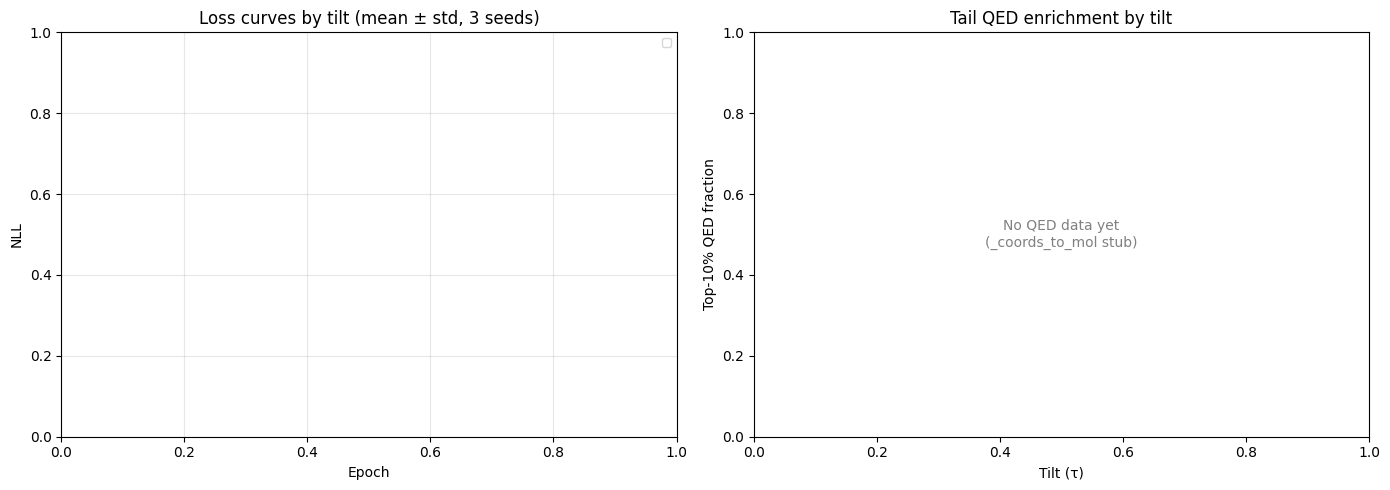

Saved → /content/ts_outputs/ablation_plots.png


In [ ]:
# ── Cell 10: Plots ────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import pandas as pd, numpy as np
from pathlib import Path

TILT_COLORS = {
    -5: '#053061', -2: '#2166ac', -1: '#74add1',
     0: '#888888',
     1: '#f46d43',  2: '#d73027',  5: '#a50026', 10: '#67001f',
}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

## Variant A: loss curves by tilt (mean ± std over seeds)
ax = axes[0]
tilt_dfs = {}
for csv_path in sorted(Path(OUTPUT_ROOT).glob('*/metrics.csv')):
    df = pd.read_csv(csv_path)
    tilt = float(df['tilt'].iloc[0])
    tilt_dfs.setdefault(tilt, []).append(df[['epoch','loss']].set_index('epoch'))

for tilt in sorted(tilt_dfs):
    combined = pd.concat(tilt_dfs[tilt], axis=1)
    mean = combined.mean(axis=1)
    std  = combined.std(axis=1).fillna(0)
    color = TILT_COLORS.get(tilt, 'black')
    ax.plot(mean.index, mean.values, color=color, label=f'τ={tilt:+.0f}', linewidth=1.8)
    ax.fill_between(mean.index, mean - std, mean + std, color=color, alpha=0.15)

ax.set_xlabel('Epoch'); ax.set_ylabel('NLL')
ax.set_title('Loss curves by tilt (mean ± std, 3 seeds)')
ax.legend(fontsize=8, ncol=2); ax.grid(alpha=0.3)

## Variant B: tail QED enrichment by tilt
ax = axes[1]
rows = []
for csv_path in sorted(Path(OUTPUT_ROOT).glob('*/metrics.csv')):
    df = pd.read_csv(csv_path).dropna(subset=['qed_tail_p10'])
    if len(df):
        rows.append({'tilt': float(df['tilt'].iloc[0]),
                     'qed_tail': df['qed_tail_p10'].max()})

if rows:
    rd = pd.DataFrame(rows).groupby('tilt')['qed_tail'].agg(['mean','std']).reset_index()
    colors = [TILT_COLORS.get(t, 'black') for t in rd['tilt']]
    ax.bar(rd['tilt'].astype(str), rd['mean'], yerr=rd['std'], color=colors, alpha=0.8, capsize=4)
    ax.axhline(0.1, color='k', linestyle='--', linewidth=1, label='Baseline 10%')
    ax.legend(); ax.grid(axis='y', alpha=0.3)
else:
    ax.text(0.5, 0.5, 'No QED data yet\n(_coords_to_mol stub)', ha='center', va='center',
            transform=ax.transAxes, fontsize=10, color='gray')

ax.set_xlabel('Tilt (τ)'); ax.set_ylabel('Top-10% QED fraction')
ax.set_title('Tail QED enrichment by tilt')

plt.tight_layout()
plot_path = os.path.join(OUTPUT_ROOT, 'ablation_plots.png')
plt.savefig(plot_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved → {plot_path}')